In [1]:
import yfinance as yf
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
disney = yf.download(tickers='dis', start='2023-01-01', end='2023-04-01', rounding=True)
disney

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,DIS,DIS,DIS,DIS,DIS
Date,,,,,
2023-01-03,86.92,87.90,85.81,86.93,14997100
2023-01-04,89.86,90.62,87.30,87.93,14957200
2023-01-05,89.81,90.35,88.43,89.55,11622600
2023-01-06,91.76,92.51,89.22,90.53,9828100
2023-01-09,92.59,93.50,91.30,92.26,11675800
...,...,...,...,...,...
2023-03-27,93.42,93.81,92.21,92.60,7487900
2023-03-28,92.64,93.79,92.41,93.31,5426100


In [3]:
disney = disney['Close']
disney

Ticker,DIS
Date,
2023-01-03,86.92
2023-01-04,89.86
2023-01-05,89.81
2023-01-06,91.76
2023-01-09,92.59
...,...
2023-03-27,93.42
2023-03-28,92.64
2023-03-29,94.64


In [4]:
disney.index = pd.to_datetime(disney.index)
len_train = int(len(disney)*0.7)
len_train

43

In [5]:
len_test = int(len(disney)*0.3)
len_test

18

In [6]:
train = disney[0:len_train]
train

Ticker,DIS
Date,
2023-01-03,86.92
2023-01-04,89.86
2023-01-05,89.81
2023-01-06,91.76
2023-01-09,92.59
2023-01-10,93.36
2023-01-11,94.11
2023-01-12,97.51
2023-01-13,97.11


In [7]:
test = disney[len_train:]
test

Ticker,DIS
Date,
2023-03-07,96.78
2023-03-08,97.02
2023-03-09,93.93
2023-03-10,91.42
2023-03-13,90.47
2023-03-14,91.21
2023-03-15,90.96
2023-03-16,92.12
2023-03-17,91.06


[ 1.00000000e+00  8.93602220e-01  8.05090982e-01  7.06831403e-01
  6.22029149e-01  5.25269486e-01  4.15453726e-01  3.00137624e-01
  2.19427767e-01  1.20856207e-01  4.15433478e-04 -1.11297807e-01
 -2.28954743e-01 -3.03361876e-01 -3.62106059e-01 -4.20797328e-01
 -4.48264051e-01]


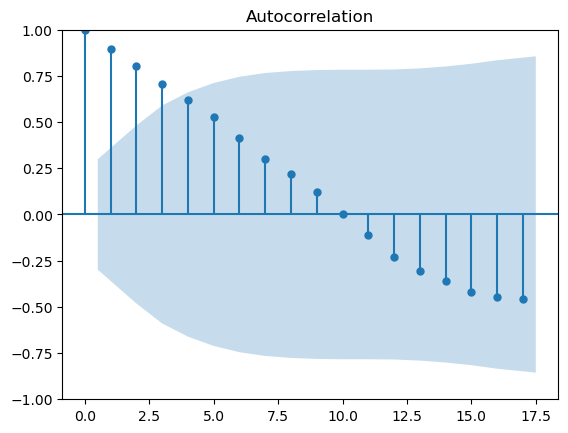

In [8]:
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

acf_array = acf(train)
print(acf_array)

#Grafico con un nivel de confianza del 95%
plot_acf(train, alpha=0.05)
plt.show()

In [9]:
from statsmodels.tsa.arima.model import ARIMA
# Fit an AR(1) model to the first simulated data
mod = ARIMA(train, order=(1,0,0))
res = mod.fit()

C:\Users\emanu\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\emanu\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\emanu\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [10]:
print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                    DIS   No. Observations:                   43
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 -85.572
Date:                Tue, 31 Mar 2026   AIC                            177.144
Time:                        15:45:50   BIC                            182.428
Sample:                             0   HQIC                           179.093
                                 - 43                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         95.7664      5.135     18.650      0.000      85.702     105.831
ar.L1          0.9717      0.031     30.948      0.000       0.910       1.033
sigma2         2.9304      0.634      4.623      0.0

In [11]:
predicciones = res.forecast(len(test))
predicciones

C:\Users\emanu\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


43    98.267041
44    98.196151
45    98.127270
46    98.060342
47    97.995311
48    97.932124
49    97.870728
50    97.811073
51    97.753109
52    97.696788
53    97.642064
54    97.588891
55    97.537226
56    97.487025
57    97.438248
58    97.390853
59    97.344802
60    97.300056
61    97.256579
Name: predicted_mean, dtype: float64

In [42]:
conf = res.get_forecast(len(test)).conf_int(alpha=0.1)
conf

C:\Users\emanu\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,lower DIS,upper DIS
43,95.403140,100.537311
44,94.152001,101.406923
45,93.948082,102.867776
46,93.738014,103.953435
47,92.722069,104.578603
48,91.604137,105.400990
49,90.885289,106.268734
50,90.473047,107.159437
51,89.936351,107.773077
52,89.258594,108.227738


In [43]:
fcast_res = res.get_forecast(len(test))
print(fcast_res.summary_frame(alpha=0.1))

DIS       mean   mean_se  mean_ci_lower  mean_ci_upper
43   97.970226  1.560677      95.403140     100.537311
44   97.779462  2.205340      94.152001     101.406923
45   98.407929  2.711394      93.948082     102.867776
46   98.845724  3.105267      93.738014     103.953435
47   98.650336  3.604131      92.722069     104.578603
48   98.502564  4.193945      91.604137     105.400990
49   98.577012  4.676235      90.885289     106.268734
50   98.816242  5.072303      90.473047     107.159437
51   98.854714  5.421980      89.936351     107.773077
52   98.743166  5.766210      89.258594     108.227738
53   98.687993  6.075680      88.694389     108.681596
54   98.725729  6.326267      88.319946     109.131512
55   98.759016  6.529428      88.019062     109.498970
56   98.706833  6.701311      87.684158     109.729509
57   98.629684  6.847476      87.366588     109.892779
58   98.588080  6.963155      87.134710     110.041450
59   98.570643  7.049787      86.974776     110.166511
60   98.53

C:\Users\emanu\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [44]:
test = pd.DataFrame(test)
predicciones = pd.DataFrame(predicciones)
test =test.reset_index()
predicciones = predicciones.reset_index()

In [45]:
test

Ticker,Date,DIS
0,2023-03-07,96.78
1,2023-03-08,97.02
2,2023-03-09,93.93
3,2023-03-10,91.42
4,2023-03-13,90.47
5,2023-03-14,91.21
6,2023-03-15,90.96
7,2023-03-16,92.12
8,2023-03-17,91.06
9,2023-03-20,92.05


In [46]:
predicciones

,index,predicted_mean
0,43,97.970226
1,44,97.779462
2,45,98.407929
3,46,98.845724
4,47,98.650336
5,48,98.502564
6,49,98.577012
7,50,98.816242
8,51,98.854714
9,52,98.743166


In [47]:
import numpy as np

acumulador1 = 0
acumulador2 = 0

for contador in range(0, 18):
    acumulador1 = acumulador1 + (test.iloc[contador][1] - predicciones.iloc[contador][1])**2
    acumulador2 = acumulador2 + np.abs((test.iloc[contador][1] - predicciones.iloc[contador][1]) / test.iloc[contador][1])

mse = acumulador1 / 18
rmse = np.round(np.sqrt(mse), 2)
mape = np.round((acumulador2 / 18) * 100, 2)
print('RMSE = ', rmse, 'MAPE = ', mape, '%')

RMSE =  5.86 MAPE =  5.91 %


In [48]:
# Pronostico de los siguientes 30 periodos posteriores al ultimo dato historico
predicciones = res.forecast(len(test) + 30)
predicciones

C:\Users\emanu\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


43    97.970226
44    97.779462
45    98.407929
46    98.845724
47    98.650336
48    98.502564
49    98.577012
50    98.816242
51    98.854714
52    98.743166
53    98.687993
54    98.725729
55    98.759016
56    98.706833
57    98.629684
58    98.588080
59    98.570643
60    98.534373
61    98.472707
62    98.414829
63    98.373755
64    98.337135
65    98.292549
66    98.244931
67    98.204591
68    98.172023
69    98.141207
70    98.109963
71    98.081724
72    98.059069
73    98.040610
74    98.024148
75    98.009718
76    97.998593
77    97.990940
78    97.985741
79    97.982276
80    97.980682
81    97.981173
82    97.983426
83    97.986896
84    97.991316
85    97.996671
86    98.002854
87    98.009586
88    98.016606
89    98.023790
90    98.031070
91    98.038326
Name: predicted_mean, dtype: float64

In [49]:
conf = res.get_forecast(len(test) + 30).conf_int(alpha=0.1)
conf

C:\Users\emanu\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,lower DIS,upper DIS
43,95.403140,100.537311
44,94.152001,101.406923
45,93.948082,102.867776
46,93.738014,103.953435
47,92.722069,104.578603
48,91.604137,105.400990
49,90.885289,106.268734
50,90.473047,107.159437
51,89.936351,107.773077
52,89.258594,108.227738


In [50]:
train = pd.DataFrame(train)
lista = test['Date']
lista = pd.DataFrame(lista)
test.index = test['Date']
test.drop(columns=['Date'], inplace=True)
test

Ticker,DIS
Date,
2023-03-07,96.78
2023-03-08,97.02
2023-03-09,93.93
2023-03-10,91.42
2023-03-13,90.47
2023-03-14,91.21
2023-03-15,90.96
2023-03-16,92.12
2023-03-17,91.06


In [51]:
k = 5
lista2 = []
for day in range(1, 30):
    fecha = ((pd.to_datetime('2023-03-31') + pd.offsets.BDay(day)).date())
    lista2.append(fecha)

lista2 = pd.DataFrame(lista2, columns = ['Date'])
lista2['Date'] = pd.to_datetime(lista2['Date'])
lista2

,Date
0,2023-04-03
1,2023-04-04
2,2023-04-05
3,2023-04-06
4,2023-04-07
5,2023-04-10
6,2023-04-11
7,2023-04-12
8,2023-04-13
9,2023-04-14


In [52]:
fechas = pd.concat([lista, lista2], ignore_index=True)
fechas = fechas.reset_index()
fechas

,index,Date
0,0,2023-03-07
1,1,2023-03-08
2,2,2023-03-09
3,3,2023-03-10
4,4,2023-03-13
5,5,2023-03-14
6,6,2023-03-15
7,7,2023-03-16
8,8,2023-03-17
9,9,2023-03-20


In [53]:
fechas.drop(columns=['index'], inplace=True)
fechas

,Date
0,2023-03-07
1,2023-03-08
2,2023-03-09
3,2023-03-10
4,2023-03-13
5,2023-03-14
6,2023-03-15
7,2023-03-16
8,2023-03-17
9,2023-03-20


In [54]:
predicciones = pd.DataFrame(predicciones)
predicciones = predicciones.reset_index()
predicciones

,index,predicted_mean
0,43,97.970226
1,44,97.779462
2,45,98.407929
3,46,98.845724
4,47,98.650336
5,48,98.502564
6,49,98.577012
7,50,98.816242
8,51,98.854714
9,52,98.743166


In [55]:
predicciones.drop(columns=['index'], inplace=True)
predicciones

,predicted_mean
0,97.970226
1,97.779462
2,98.407929
3,98.845724
4,98.650336
5,98.502564
6,98.577012
7,98.816242
8,98.854714
9,98.743166


In [56]:
frames = [fechas, predicciones]
result = pd.concat(frames, axis=1, join='inner')
result.columns = ['Date', 'Prediciones']
result

,Date,Prediciones
0,2023-03-07,97.970226
1,2023-03-08,97.779462
2,2023-03-09,98.407929
3,2023-03-10,98.845724
4,2023-03-13,98.650336
5,2023-03-14,98.502564
6,2023-03-15,98.577012
7,2023-03-16,98.816242
8,2023-03-17,98.854714
9,2023-03-20,98.743166


In [57]:
print(result.dtypes)

Date           datetime64[ns]
Prediciones           float64
dtype: object


In [58]:
result.index = result['Date']
result.drop(columns=['Date'], inplace=True)
result

,Prediciones
Date,
2023-03-07,97.970226
2023-03-08,97.779462
2023-03-09,98.407929
2023-03-10,98.845724
2023-03-13,98.650336
2023-03-14,98.502564
2023-03-15,98.577012
2023-03-16,98.816242
2023-03-17,98.854714


In [59]:
conf = conf.reset_index()
conf.drop(columns=['index'], inplace=True)
conf

,lower DIS,upper DIS
0,95.403140,100.537311
1,94.152001,101.406923
2,93.948082,102.867776
3,93.738014,103.953435
4,92.722069,104.578603
5,91.604137,105.400990
6,90.885289,106.268734
7,90.473047,107.159437
8,89.936351,107.773077
9,89.258594,108.227738


In [60]:
frames = [fechas, conf]
intervalos =pd.concat(frames, axis=1, join='inner')
intervalos

,Date,lower DIS,upper DIS
0,2023-03-07,95.403140,100.537311
1,2023-03-08,94.152001,101.406923
2,2023-03-09,93.948082,102.867776
3,2023-03-10,93.738014,103.953435
4,2023-03-13,92.722069,104.578603
5,2023-03-14,91.604137,105.400990
6,2023-03-15,90.885289,106.268734
7,2023-03-16,90.473047,107.159437
8,2023-03-17,89.936351,107.773077
9,2023-03-20,89.258594,108.227738


In [61]:
intervalos.index =intervalos['Date']
intervalos.drop(columns=['Date'], inplace=True)
intervalos

,lower DIS,upper DIS
Date,,
2023-03-07,95.403140,100.537311
2023-03-08,94.152001,101.406923
2023-03-09,93.948082,102.867776
2023-03-10,93.738014,103.953435
2023-03-13,92.722069,104.578603
2023-03-14,91.604137,105.400990
2023-03-15,90.885289,106.268734
2023-03-16,90.473047,107.159437
2023-03-17,89.936351,107.773077


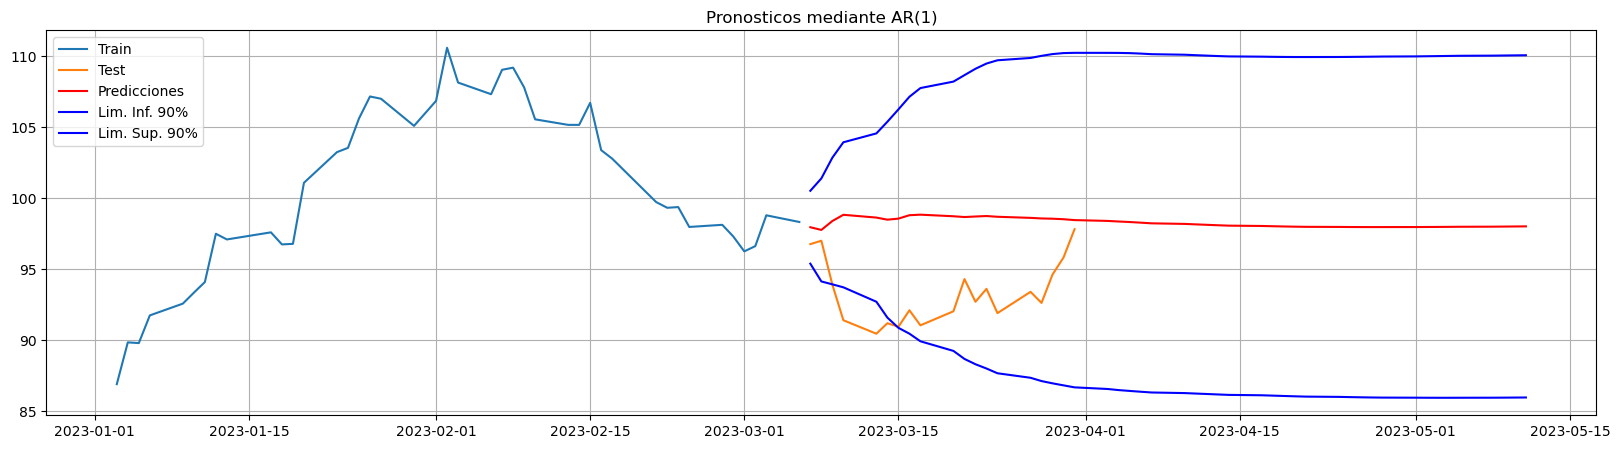

In [62]:
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(result, label='Predicciones', color='red')
plt.plot(intervalos['lower DIS'], label = 'Lim. Inf. 90%', color = 'blue')
plt.plot(intervalos['upper DIS'], label = 'Lim. Sup. 90%', color = 'blue')
plt.legend(loc='best')
plt.title('Pronosticos mediante AR(1)')
plt.show()

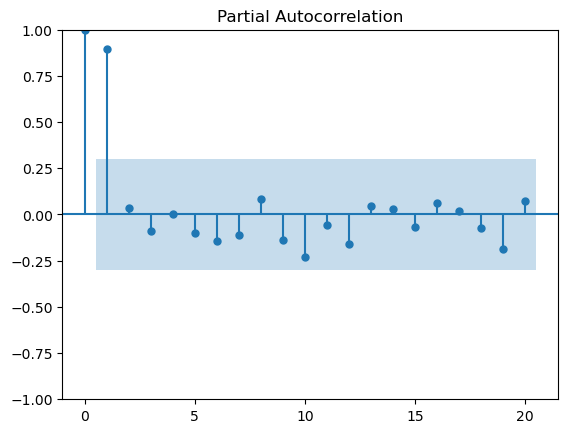

In [63]:
# Determinacion del valor adecuado de p para AR(p) a partir de la funcion de Autocorrelacion parcial
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(train, lags=20)
plt.show()

C:\Users\emanu\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\emanu\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\emanu\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\emanu\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so wil

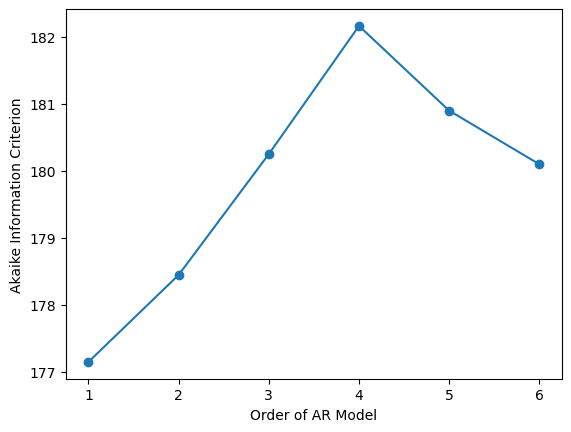

In [64]:
# Determinacion del valor adecuado de p para AR(p) a partir del criterio de informacion Akaike
# Fit the data to an AR(p) for p = 0, ...., 6, and save the AIC
AIC = np.zeros(7)
for p in range(7):
    mod = ARIMA(train, order=(p,0,0))
    res = mod.fit()
# Save AIC for AR(p)
    AIC[p] = res.aic

# Plot the BIC as a function of p
plt.plot(range(1,7), AIC[1:7], marker='o')
plt.xlabel('Order of AR Model')
plt.ylabel('Akaike Information Criterion')
plt.show()

C:\Users\emanu\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\emanu\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\emanu\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\emanu\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so wil

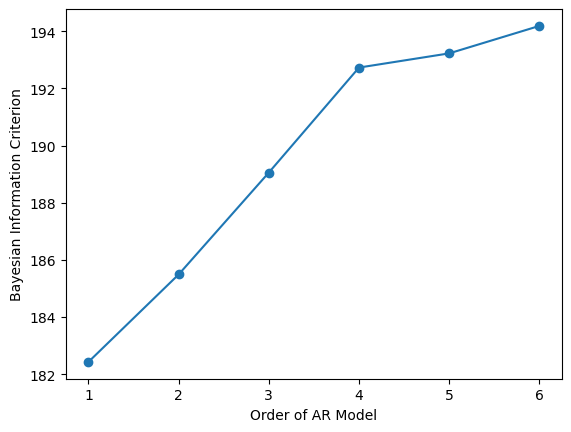

In [65]:
# Determinacion del valor adecuado de p para AR(p) a partir del criterio de informacion Bayesiano
# Fit the data to an AR(p) for p = 0, ...., 6, and save the BIC
BIC = np.zeros(7)
for p in range(7):
    mod = ARIMA(train, order=(p,0,0))
    res = mod.fit()
# Save BIC for AR(p)
    BIC[p] = res.bic

# Plot the BIC as a function of p
plt.plot(range(1,7), BIC[1:7], marker='o')
plt.xlabel('Order of AR Model')
plt.ylabel('Bayesian Information Criterion')
plt.show()